# <span style="font-family: Arial; color:#1D90FF">GBDT Leaf WOE Notebook</span>

## <span style="font-family: Arial; color:navyblue">Tree Interaction Features for Credit Scoring</span>

In this notebook, we show how to convert trees to indices and use them to compute WOE.

- Repo for xbooster: <a href="https://github.com/xRiskLab/xBooster">https://github.com/xRiskLab/xBooster</a>
- Repo for fastwoe: <a href="https://github.com/xRiskLab/fastwoe">https://github.com/xRiskLab/fastwoe</a>

Author: https://www.github.com/deburky


In [112]:
import pandas as pd
import xgboost as xgb
from fastwoe import FastWoe
from fastwoe.plots import plot_performance
from matplotlib import pyplot as plt
from rich.console import Console
from rich.panel import Panel
from rich.table import Table
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score
from sklearn.model_selection import train_test_split
from xbooster.xgb_constructor import XGBScorecardConstructor

In [50]:
# Fetch blended credit data
url = (
    "https://drive.google.com/file/d/1Is8UZnPRExI-SLJMle8GRbFGpha5IvYZ/view?usp=sharing"
)
url = "https://drive.google.com/uc?id=" + url.split("/")[-2]
dataset = pd.read_csv(url, index_col=False)

features = [
    "external_risk_estimate",
    "revolving_utilization_of_unsecured_lines",
    "account_never_delinq_percent",
    "net_fraction_revolving_burden",
    "num_total_cc_accounts",
    "average_months_in_file",
]

X, y = dataset[features], dataset["is_bad"]

ix_train, ix_test = train_test_split(
    X.index, stratify=y, test_size=0.3, random_state=62
)

## Train a model and get tree leaves

In [56]:
model = xgb.XGBClassifier(n_estimators=100, max_depth=3, learning_rate=0.1)
model.fit(X.loc[ix_train], y.loc[ix_train])

constructor = XGBScorecardConstructor(model, X.loc[ix_train], y.loc[ix_train])
scorecard = constructor.construct_scorecard()

trees_df = constructor.get_leafs(X.loc[ix_test], output_type="leaf_index")

(trees_df.head()
 .style
 .set_table_styles([{"selector": "th", "props": [("font-family", "Arial, sans-serif")]}])
 .set_properties(**{"font-family": "Arial, sans-serif"})
 .format("{:.0f}")
)

,tree_0,tree_1,tree_2,tree_3,tree_4,tree_5,tree_6,tree_7,tree_8,tree_9,tree_10,tree_11,tree_12,tree_13,tree_14,tree_15,tree_16,tree_17,tree_18,tree_19,tree_20,tree_21,tree_22,tree_23,tree_24,tree_25,tree_26,tree_27,tree_28,tree_29,tree_30,tree_31,tree_32,tree_33,tree_34,tree_35,tree_36,tree_37,tree_38,tree_39,tree_40,tree_41,tree_42,tree_43,tree_44,tree_45,tree_46,tree_47,tree_48,tree_49,tree_50,tree_51,tree_52,tree_53,tree_54,tree_55,tree_56,tree_57,tree_58,tree_59,tree_60,tree_61,tree_62,tree_63,tree_64,tree_65,tree_66,tree_67,tree_68,tree_69,tree_70,tree_71,tree_72,tree_73,tree_74,tree_75,tree_76,tree_77,tree_78,tree_79,tree_80,tree_81,tree_82,tree_83,tree_84,tree_85,tree_86,tree_87,tree_88,tree_89,tree_90,tree_91,tree_92,tree_93,tree_94,tree_95,tree_96,tree_97,tree_98,tree_99
0,12,6,12,12,12,14,14,12,11,14,14,11,14,12,13,14,14,11,14,12,11,14,13,12,14,14,12,14,11,14,14,14,11,14,10,14,14,12,14,12,12,14,13,10,7,12,12,12,10,10,14,14,7,12,13,10,12,12,14,13,12,7,10,12,12,6,10,7,6,12,12,13,6,7,11,5,6,12,12,14,6,9,5,6,14,14,11,5,12,14,10,5,14,14,13,9,5,14,5,14
1,8,8,7,8,7,7,9,7,8,7,8,9,10,7,7,9,7,9,7,9,7,8,9,7,11,8,7,8,9,13,7,7,9,14,7,9,7,12,11,8,8,11,13,7,7,7,11,11,8,10,11,7,7,12,7,10,12,12,14,7,8,7,10,9,12,6,8,7,6,11,9,11,6,7,9,5,6,12,9,7,6,9,5,6,14,8,7,6,7,8,10,5,14,11,7,9,5,13,5,7
2,5,6,5,5,5,12,13,5,5,12,13,5,13,5,12,13,12,5,12,5,5,11,12,5,13,12,5,11,4,12,11,12,4,12,13,13,14,11,9,11,5,9,12,11,7,5,13,11,9,4,9,12,7,4,10,10,4,4,14,10,12,7,4,12,4,6,9,7,6,4,12,9,6,7,4,5,6,4,12,10,6,3,5,6,9,8,5,5,11,8,3,5,14,9,10,4,5,10,5,8
3,10,9,10,9,10,8,10,8,9,10,7,10,9,10,7,10,9,10,7,8,10,10,9,10,10,7,7,10,10,10,7,7,10,10,13,10,7,10,14,8,10,14,8,9,7,7,13,7,7,10,12,7,7,12,13,10,12,12,14,13,9,7,10,12,12,6,7,7,6,11,12,14,6,7,12,5,6,12,12,14,6,9,5,6,14,14,10,5,7,14,10,5,14,14,13,9,5,13,5,14
4,8,8,8,8,8,9,9,9,8,7,9,10,7,8,11,10,8,10,11,9,8,10,11,8,12,12,7,10,4,13,10,12,4,12,8,13,7,12,13,13,10,13,13,8,7,10,11,13,14,10,10,14,7,12,10,14,11,12,14,10,6,7,10,12,12,6,12,7,6,12,12,10,6,11,10,6,6,12,12,10,6,9,5,6,14,10,10,6,10,10,10,5,14,10,10,9,5,14,5,10


## Generate WOE trees

In [57]:
# For each tree column in trees_df
for col in trees_df.columns:
    tree_num = int(col.replace("tree_", ""))  # Extract tree number

    # Create mapping for this tree: Node -> DetailedSplit
    tree_scorecard = scorecard[scorecard["Tree"] == tree_num].set_index("Node")[
        "DetailedSplit"
    ]

    # Replace node IDs with DetailedSplit
    trees_df[col] = trees_df[col].map(tree_scorecard)

woe_encoder = FastWoe()

USE_TREES = False
if USE_TREES:
    trees = [
        "tree_3",
        "tree_1",
        "tree_8",
        "tree_4",
        "tree_0",
        "tree_6",
        "tree_9",
        "tree_23",
        "tree_13",
        "tree_20",
        "tree_17",
        "tree_14",
    ]
    trees_df = trees_df[trees].copy()
woe_encoder.fit(trees_df, y.loc[ix_test])

preds = woe_encoder.predict_proba(trees_df)[:, 1]
gini_woe = roc_auc_score(y.loc[ix_test], preds) * 2 - 1
print(gini_woe)

summary = pd.DataFrame(woe_encoder.feature_stats_).T

# Get feature (tree) and gini, sort by gini and take top 10
results = summary[["feature", "gini"]].copy()
top_10_trees = results.sort_values("gini", ascending=False).head(10).reset_index(drop=True)
df = top_10_trees.T
df.index.name = None

(df.style
 .background_gradient(subset=pd.IndexSlice[["gini"], :], cmap="Greens", vmin=0.8, vmax=0.86)
 .hide(axis="columns")
 .set_table_styles([{"selector": "th", "props": [("font-family", "Arial, sans-serif")]}])
 .set_properties(**{"font-family": "Arial, sans-serif"})
 .format(lambda x: f"{x:.3f}" if isinstance(x, float) else x)
)

0.8562320987654322


feature,tree_3,tree_1,tree_8,tree_4,tree_2,tree_7,tree_0,tree_6,tree_5,tree_9
gini,0.843,0.841,0.837,0.835,0.831,0.831,0.831,0.825,0.821,0.820


In [58]:
df = scorecard.query("Tree == 3")[["Tree", "Node", "DetailedSplit", "CountPct", "EventRate"]]
df.style.set_properties(**{
    "white-space": "pre-wrap",
    "font-family": "Arial, sans-serif"
}).set_properties(subset=["DetailedSplit"], **{
    "max-width": "300px"
}).set_table_styles([{
    "selector": "th",
    "props": [("font-family", "Arial, sans-serif")]
}])

,Tree,Node,DetailedSplit,CountPct,EventRate
21,3,5,"account_never_delinq_percent >= 98.4000015 or missing, revolving_utilization_of_unsecured_lines < 0.697415113",0.490143,0.001749
22,3,7,"account_never_delinq_percent < 98.4000015, revolving_utilization_of_unsecured_lines < 0.503930151, external_risk_estimate < 71",0.087857,0.232520
23,3,8,"account_never_delinq_percent < 98.4000015, revolving_utilization_of_unsecured_lines < 0.503930151, external_risk_estimate >= 71 or missing",0.168143,0.047579
24,3,9,"account_never_delinq_percent < 98.4000015, revolving_utilization_of_unsecured_lines >= 0.503930151 or missing, external_risk_estimate < 84",0.124429,0.528129
25,3,10,"account_never_delinq_percent < 98.4000015, revolving_utilization_of_unsecured_lines >= 0.503930151 or missing, external_risk_estimate >= 84 or missing",0.024857,0.103448
26,3,11,"account_never_delinq_percent >= 98.4000015 or missing, revolving_utilization_of_unsecured_lines >= 0.697415113 or missing, external_risk_estimate < 61",0.011571,0.123457
27,3,12,"account_never_delinq_percent >= 98.4000015 or missing, revolving_utilization_of_unsecured_lines >= 0.697415113 or missing, external_risk_estimate >= 61 or missing",0.093000,0.010753


## Pipeline


In [ ]:
model = xgb.XGBClassifier(n_estimators=100, max_depth=3, learning_rate=0.1)
model.fit(X.loc[ix_train], y.loc[ix_train])

constructor = XGBScorecardConstructor(model, X.loc[ix_train], y.loc[ix_train])
scorecard = constructor.construct_scorecard()

def get_tree_features(X_subset):
    trees_df = constructor.get_leafs(X_subset, output_type="leaf_index")
    for col in trees_df.columns:
        tree_num = int(col.replace("tree_", ""))
        tree_scorecard = scorecard[scorecard["Tree"] == tree_num].set_index("Node")["DetailedSplit"]
        trees_df[col] = trees_df[col].map(tree_scorecard)
    return trees_df

selected_trees = [
    "tree_3", "tree_1", "tree_8", "tree_4", "tree_0",
    "tree_6", "tree_9", "tree_23", "tree_13", "tree_20",
    "tree_17", "tree_14",
]

trees_train = get_tree_features(X.loc[ix_train])[selected_trees]
trees_train.index = X.loc[ix_train].index

trees_test = get_tree_features(X.loc[ix_test])[selected_trees]
trees_test.index = X.loc[ix_test].index

woe_trees = FastWoe()
woe_trees.fit(trees_train, y.loc[ix_train])

woe_main = FastWoe()
woe_main.fit(X.loc[ix_train], y.loc[ix_train])

X_train_combined = pd.concat([
    woe_main.transform(X.loc[ix_train]),
    woe_trees.transform(trees_train)
], axis=1)

X_test_combined = pd.concat([
    woe_main.transform(X.loc[ix_test]),
    woe_trees.transform(trees_test)
], axis=1)

lr = LogisticRegression(max_iter=1000)
lr.fit(X_train_combined, y.loc[ix_train])

preds_train = lr.predict_proba(X_train_combined)[:, 1]
preds_test = lr.predict_proba(X_test_combined)[:, 1]
gini_train = roc_auc_score(y.loc[ix_train], preds_train) * 2 - 1
gini_test = roc_auc_score(y.loc[ix_test], preds_test) * 2 - 1

preds_xgb_train = model.predict_proba(X.loc[ix_train])[:, 1]
preds_xgb_test = model.predict_proba(X.loc[ix_test])[:, 1]
gini_xgb_train = roc_auc_score(y.loc[ix_train], preds_xgb_train) * 2 - 1
gini_xgb_test = roc_auc_score(y.loc[ix_test], preds_xgb_test) * 2 - 1

# Print with rich console
console = Console()

xgb_table = Table(show_header=True, header_style="bold cyan", box=None)
xgb_table.add_column("Metric", style="dim")
xgb_table.add_column("Value", justify="right")
xgb_table.add_row("Train Gini", f"{gini_xgb_train:.2%}")
xgb_table.add_row("Test Gini", f"{gini_xgb_test:.2%}")
xgb_table.add_row("Overfit", f"{(gini_xgb_train - gini_xgb_test):.2%}")

woe_table = Table(show_header=True, header_style="bold green", box=None)
woe_table.add_column("Metric", style="dim")
woe_table.add_column("Value", justify="right")
woe_table.add_row("Train Gini", f"{gini_train:.2%}")
woe_table.add_row("Test Gini", f"{gini_test:.2%}")
woe_table.add_row("Overfit", f"{(gini_train - gini_test):.2%}")

console.print(Panel(xgb_table, title="XGBoost (100 trees)", border_style="cyan", width=28))
console.print(Panel(woe_table, title="WOE-LR (+interactions)", border_style="green", width=25))

╭── XGBoost (100 trees) ───╮
│  Metric       Value      │
│  Train Gini  92.30%      │
│  Test Gini   88.97%      │
│  Overfit      3.33%      │
╰──────────────────────────╯

╭─ WOE-LR (+interactions) ─╮
│  Metric       Value      │
│  Train Gini  89.20%      │
│  Test Gini   88.67%      │
│  Overfit      0.53%      │
╰──────────────────────────╯

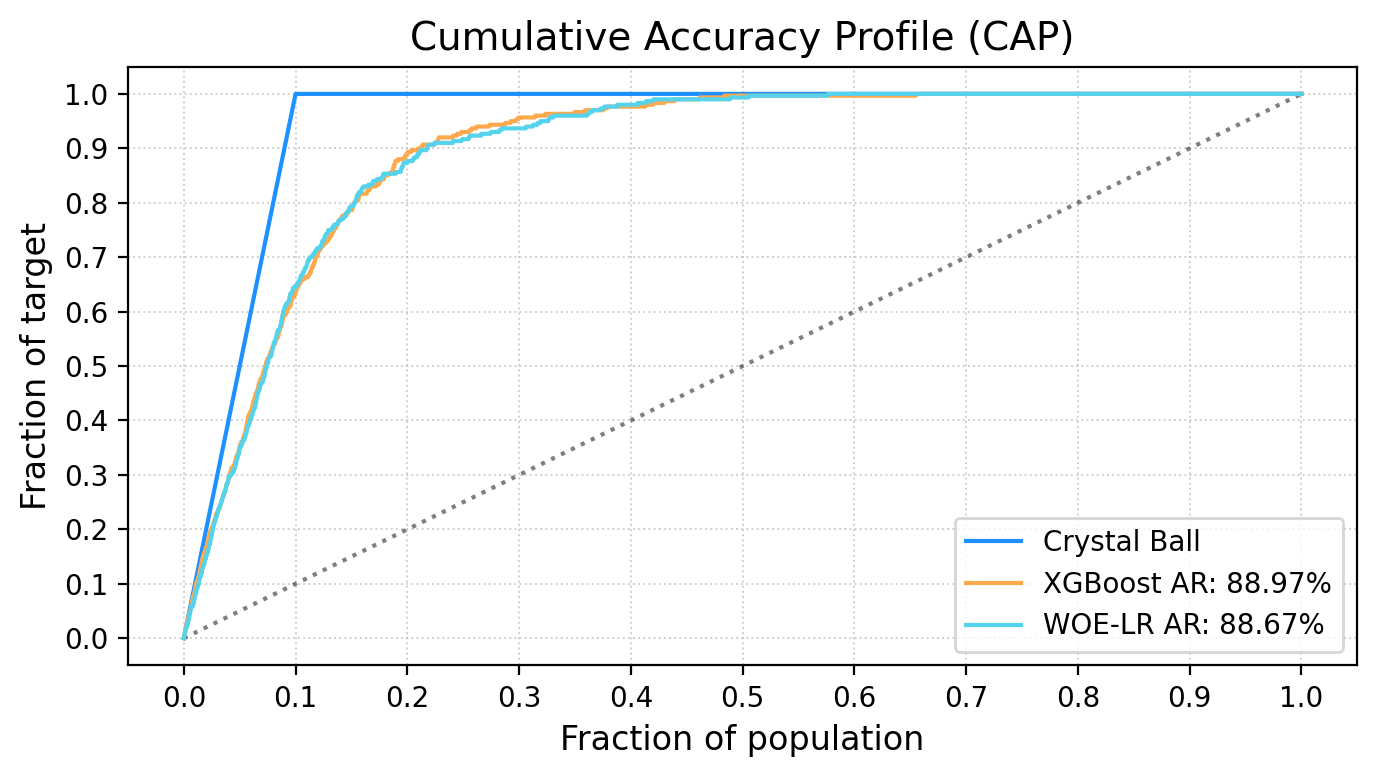

In [120]:
%config InlineBackend.figure_format = 'retina'
custom_colors = ["#ffa94d", "#55d3ed"]

fig, ax = plt.subplots(1, 1, figsize=(7, 4))

_, _, ginis = plot_performance(
    y.loc[ix_test],
    [preds_xgb_test, preds_test],
    ax=ax,
    labels=["XGBoost", "WOE-LR"],
    colors=custom_colors,
)

plt.tight_layout()
plt.show()